In [1]:
# Grendel model
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import math
import matplotlib as mpl
from combined_model_v2 import combined_full_model

plt.rcParams.update(plt.rcParamsDefault)

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.frameon": False,
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "xtick.top": True,
    "ytick.right": True,
})

In [2]:
def test_model(test_folder_name, z_list, dNeff_shift=0, fidm_shift=0, 
               base_path="/home/storgaard/OneDrive/Speciale/HALOFIT/C_256+2048",
               num_bins=25, res_lims = [-5, 5]):
    """
    Dynamically loads N-body data, log-bins it to reduce noise, 
    and compares it against emulator predictions.
    """
    
    num_plots = len(z_list)
    cols = 2
    rows = math.ceil(num_plots / cols)
    
    fig = plt.figure(figsize=(14, 5 * rows))
    gs_outer = gridspec.GridSpec(rows, cols, wspace=0.25, hspace=0.15)

    for i, z in enumerate(z_list):
        row = i // cols
        col = i % cols
        
        # Construct path based on the .dat format seen in your folder images
        file_name = f"Ck_z{z:.2f}.txt"
        file_path = os.path.join(base_path, test_folder_name, file_name)
        
        try:
            # 1. Load Raw N-body data
            data = np.loadtxt(file_path, skiprows=1)  # Assuming first row is header
            raw_k = data[:, 0]
            raw_C = data[:, 1]
            
            # 2. Log-k Binning (Matches emulator training logic)
            # Create 25 log-spaced bins
            k_bins = np.logspace(np.log10(raw_k.min()), np.log10(raw_k.max()), num_bins + 1)
            data_k = []
            data_C = []
            
            for j in range(num_bins):
                mask = (raw_k >= k_bins[j]) & (raw_k < k_bins[j+1])
                if np.any(mask):
                    # Geometric mean for k (center of log bin), arithmetic mean for C
                    data_k.append(np.exp(np.mean(np.log(raw_k[mask]))))
                    data_C.append(np.mean(raw_C[mask]))
            
            data_k = np.array(data_k)
            data_C = np.array(data_C)

            # 3. Get Emulator Prediction
            model_res = combined_full_model(data_k, z, dNeff_shift, fidm_shift)
            model_k = model_res['k']
            model_C = model_res['C']

            # 4. Calculate Residuals (%)
            residuals_pct = (data_C / model_C - 1) * 100

            # --- Plotting Grid ---
            gs_inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_outer[row, col], 
                                                        height_ratios=[3, 1], hspace=0.11)
            
            ax_main = fig.add_subplot(gs_inner[0])
            ax_res  = fig.add_subplot(gs_inner[1], sharex=ax_main)

            # --- Main Plot ---
            ax_main.scatter(data_k, data_C, color='tab:blue', alpha=0.6, s=25, label='CONCEPT data')
            ax_main.plot(model_k, model_C, color='tab:orange', lw=2.5, label='Model', zorder=10)
            
            ax_main.set_xscale('log')
            ax_main.set_ylabel(r'$C(k)$')
            ax_main.text(0.82, 0.95, f'$z = {z}$', transform=ax_main.transAxes, 
                         verticalalignment='top', fontweight='bold')
            
            if i == 0:
                ax_main.legend(frameon=False, loc='lower left')
            plt.setp(ax_main.get_xticklabels(), visible=False)

            # --- Residual Plot ---
            ax_res.axhline(0, color='black', lw=1, ls='--')
            ax_res.plot(data_k, residuals_pct, 'o', markersize=4, color='tab:blue', alpha=0.7)

            ax_res.set_ylabel(r'Res [%]')
            if row == rows - 1:
                ax_res.set_xlabel(r'$k$ [$1/\mathrm{Mpc}$]')
            ax_res.set_ylim(*res_lims) 
            
            # Reference lines at +/- 2% 
            ax_res.hlines([2, -2], color='grey', lw=1, ls='--', 
                          xmin=data_k.min() - 0.1, xmax=data_k.max() + 2)

        except FileNotFoundError:
            print(f"Warning: File {file_path} not found. Skipping redshift z={z}.")

    plt.show()

    fig.savefig(f"{test_folder_name}.pdf", dpi=300, bbox_inches='tight')

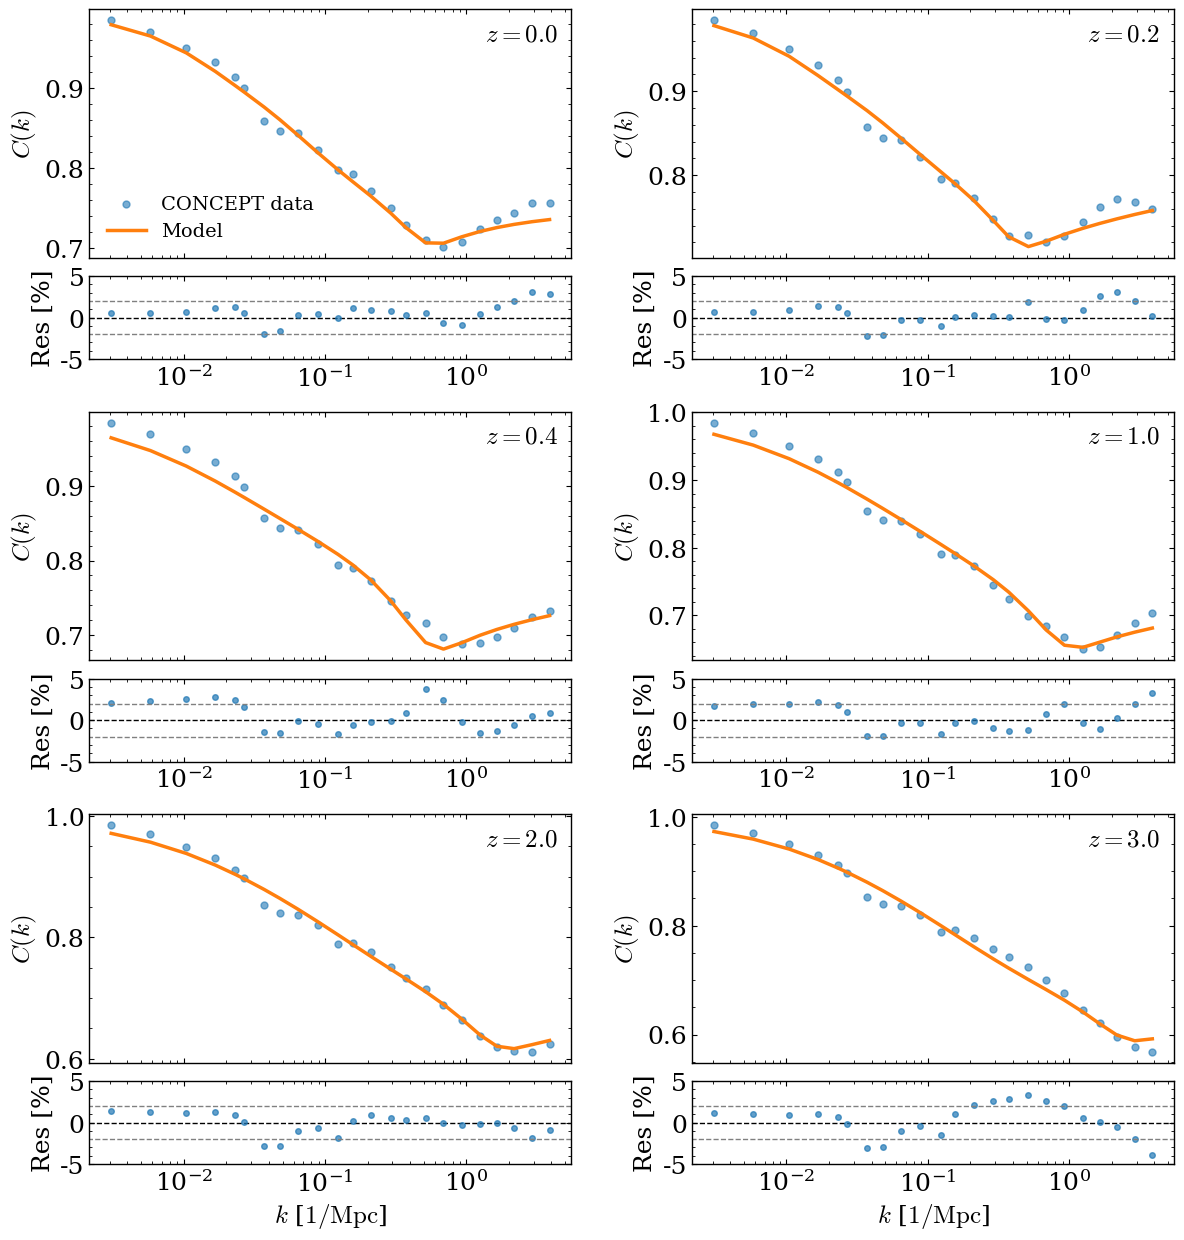

In [3]:
# For Test 1 (dNeff=1.75, fidm=-1.75)
test_model(
    test_folder_name="test_1", 
    z_list=[0.0, 0.2, 0.4, 1.0, 2.0, 3.0], 
    dNeff_shift=1.75, 
    fidm_shift=-1.75
)

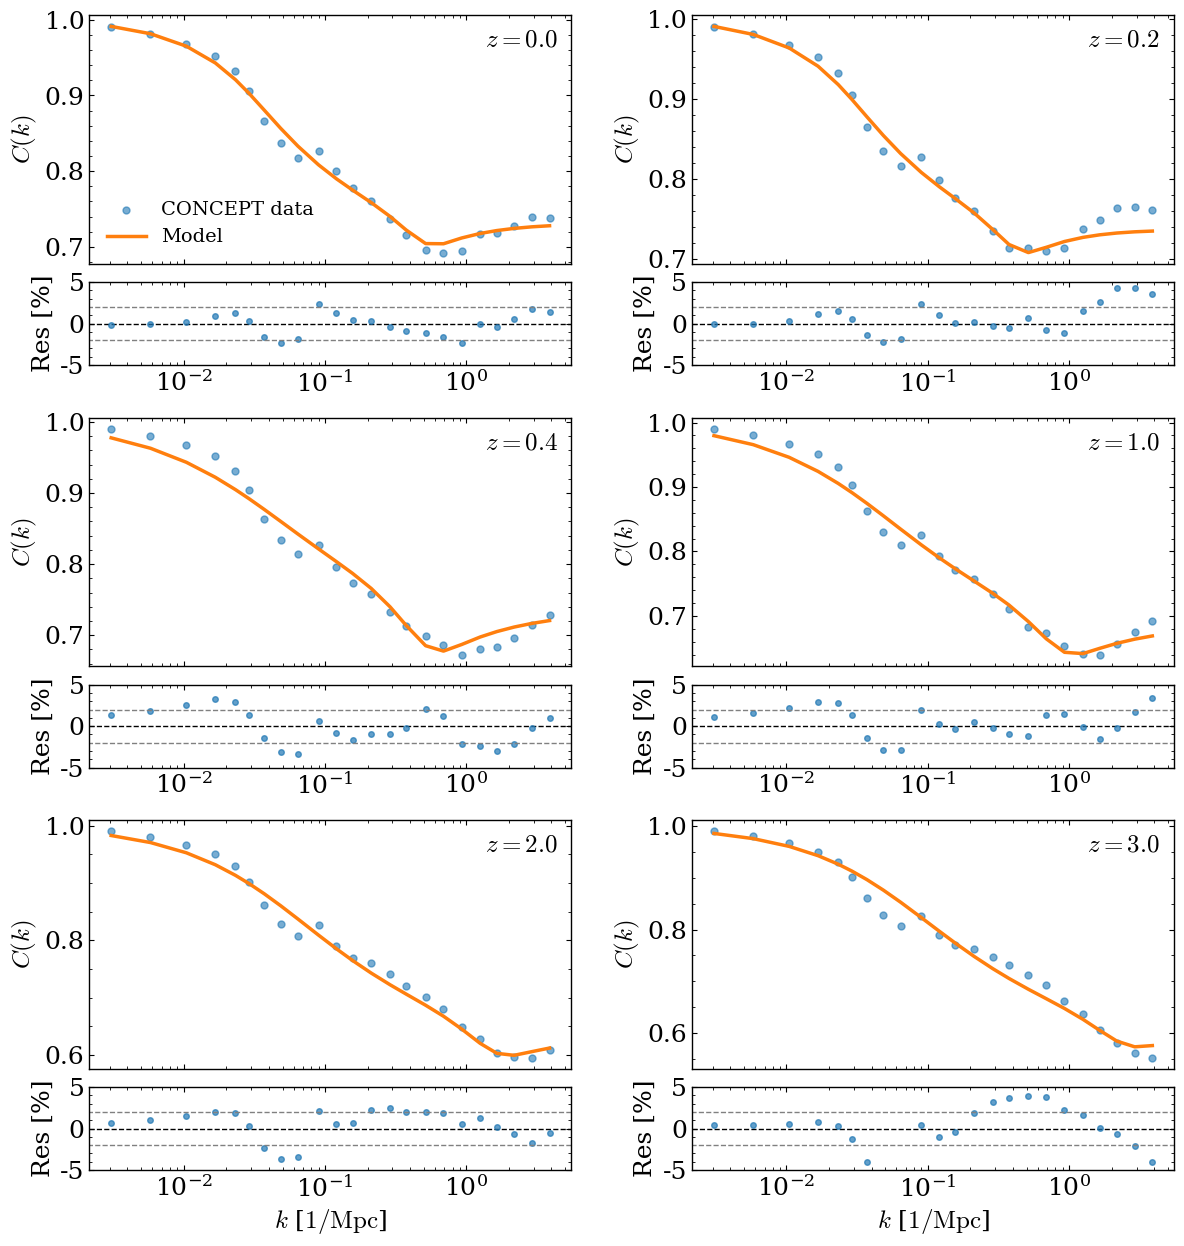

In [4]:
# For Test 2 (dNeff=-0.25, fidm=2.0)
test_model(
    test_folder_name="test_2", 
    z_list=[0.0, 0.2, 0.4, 1.0, 2.0, 3.0], 
    dNeff_shift=-0.25, 
    fidm_shift=2.0
)

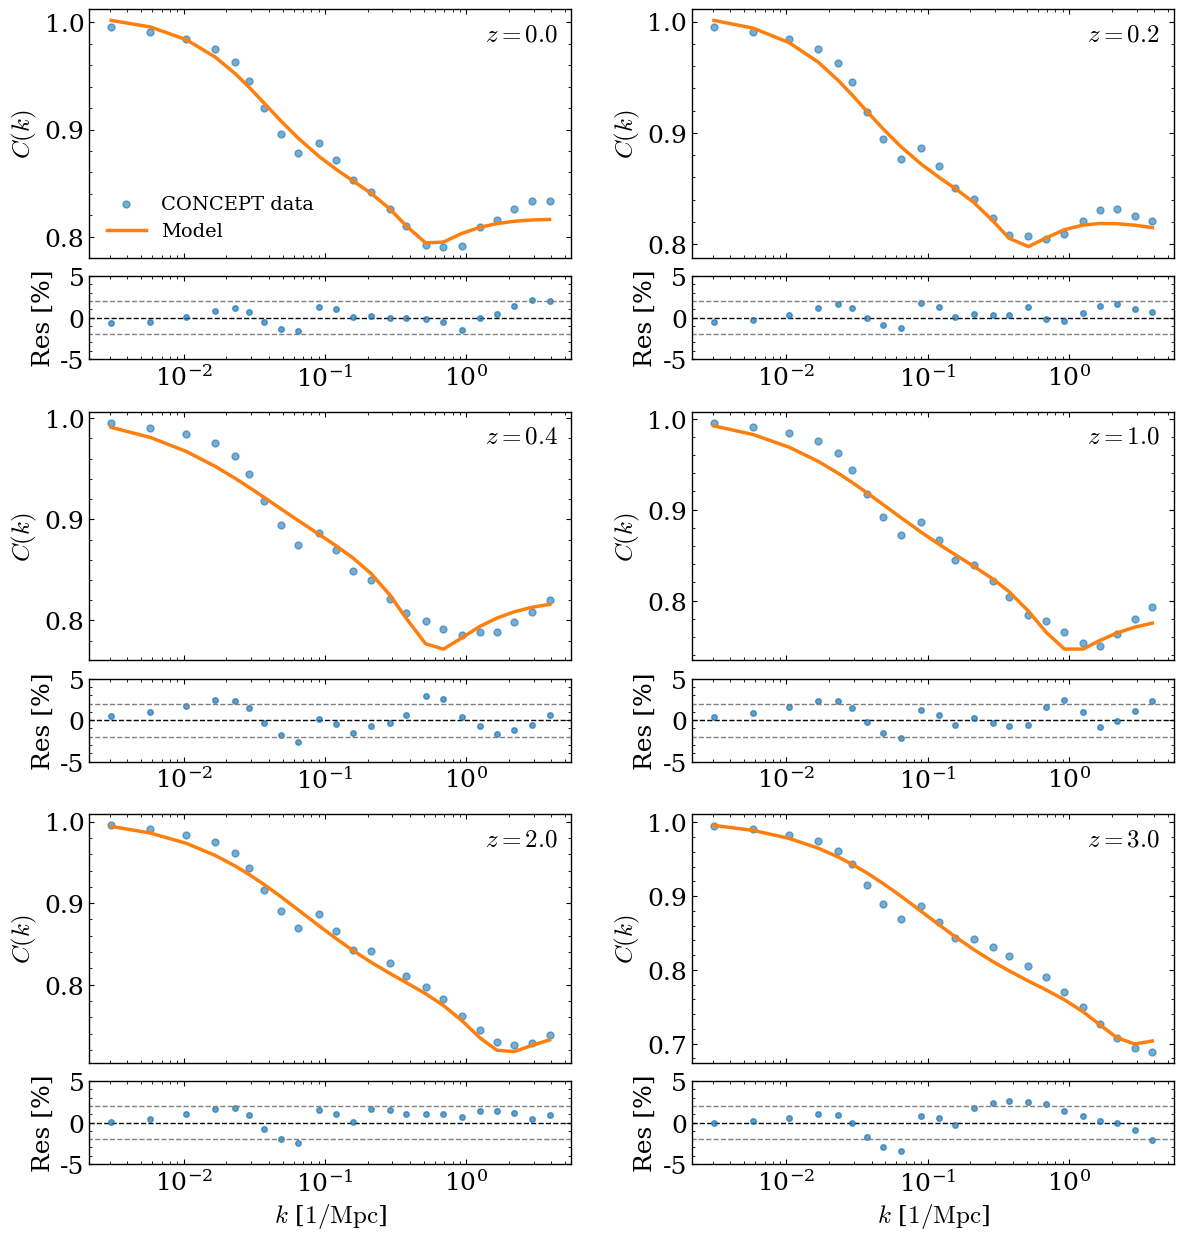

In [5]:
# For Test 3 (dNeff=-2.0, fidm=0.75)
test_model(
    test_folder_name="test_3", 
    z_list=[0.0, 0.2, 0.4, 1.0, 2.0, 3.0], 
    dNeff_shift=-2.0, 
    fidm_shift=0.75
)

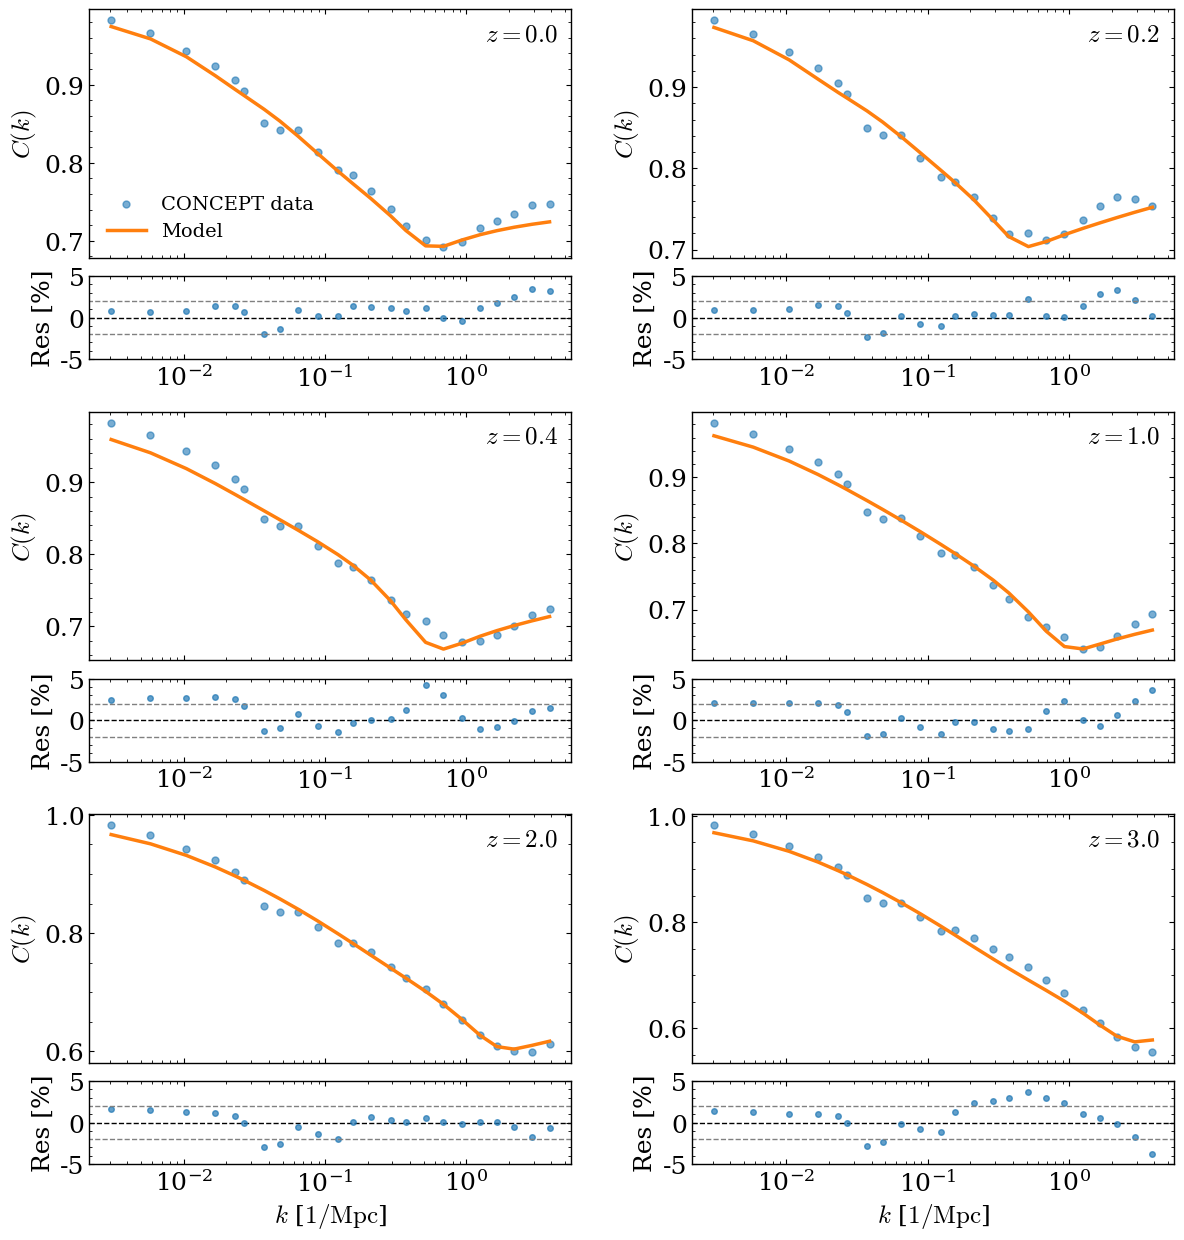

In [6]:
# For Test 4 (dNeff=+2.50, fidm=-2.5, extrapolation test)
test_model(
    test_folder_name="test_4", 
    z_list=[0.0, 0.2, 0.4, 1.0, 2.0, 3.0], 
    dNeff_shift=2.5, 
    fidm_shift=-2.5
)

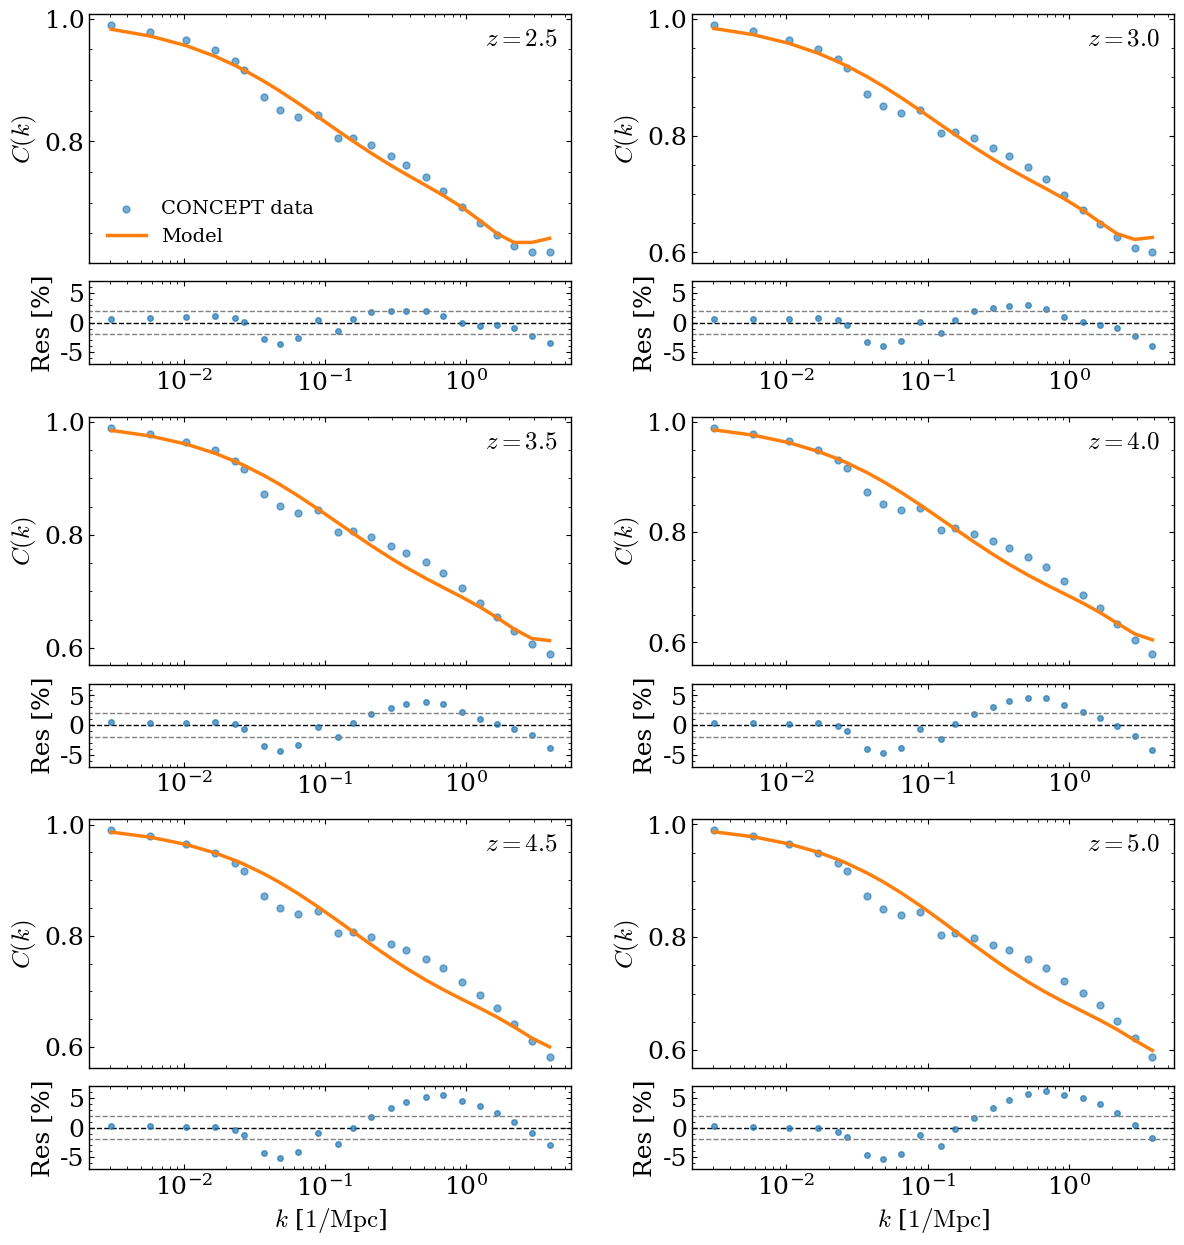

In [7]:
# For Test 5 (Baseline, but at high-z to check extrapolation)
test_model(
    test_folder_name="test_5", 
    z_list=[2.5, 3.0, 3.5, 4.0, 4.5, 5.0], 
    dNeff_shift=0.0, 
    fidm_shift=0.0, res_lims=[-7, 7]
)

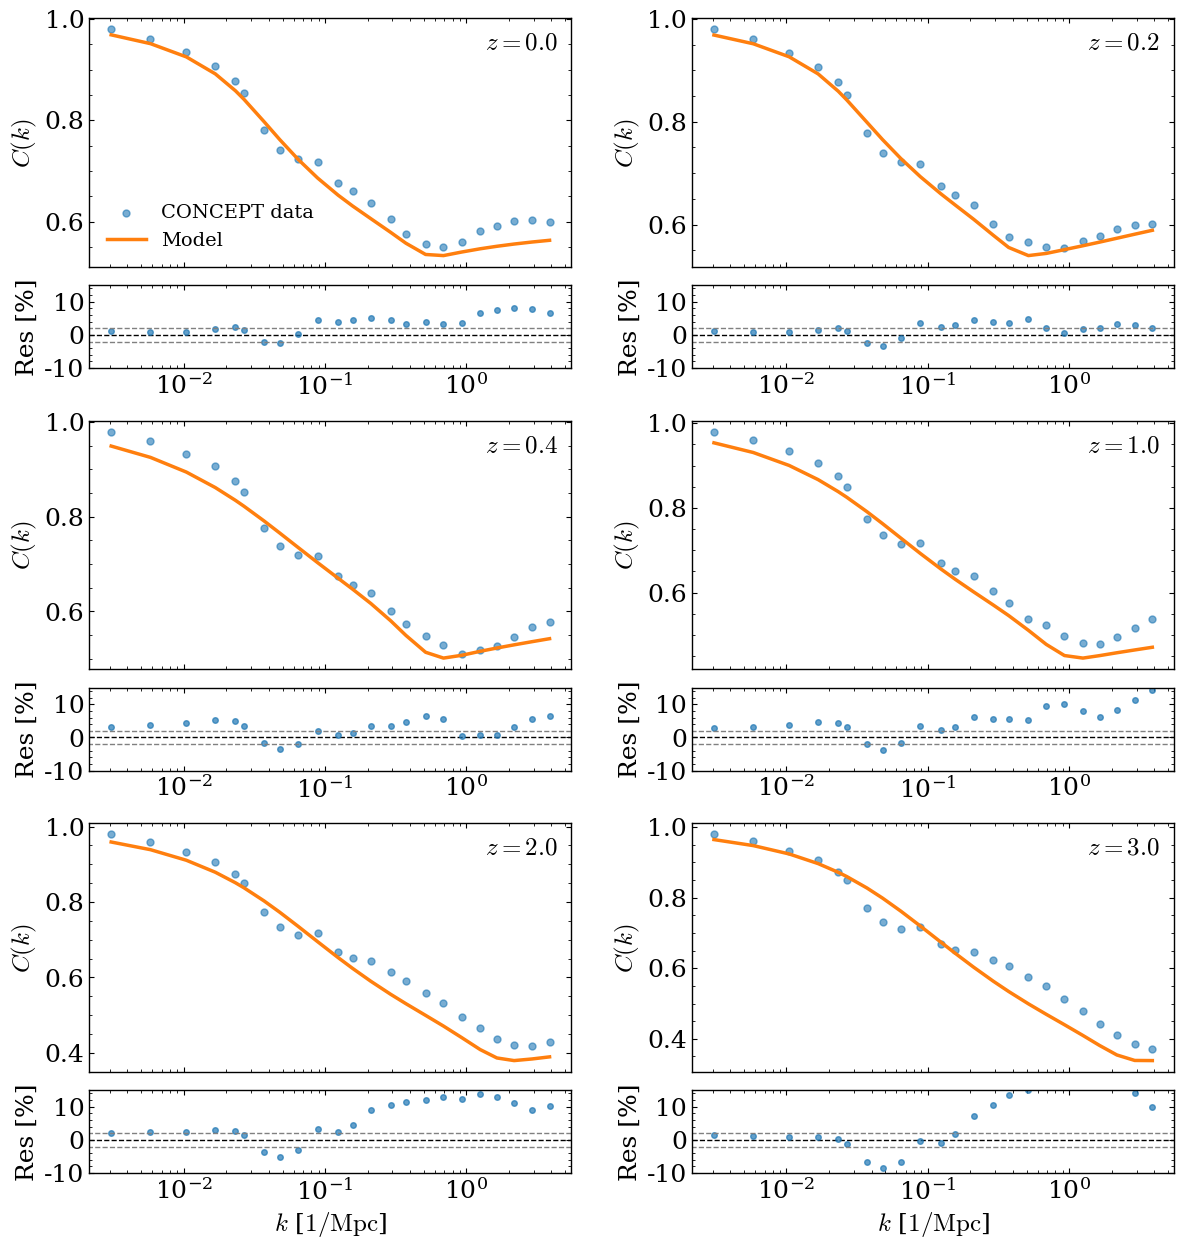

In [8]:
# For Test 6 (dNeff=+3.5, fidm=+3.5, extrapolation test)
test_model(
    test_folder_name="test_6", 
    z_list=[0.0, 0.2, 0.4, 1.0, 2.0, 3.0], 
    dNeff_shift=3.5, 
    fidm_shift=3.5, res_lims=[-10, 15]
)

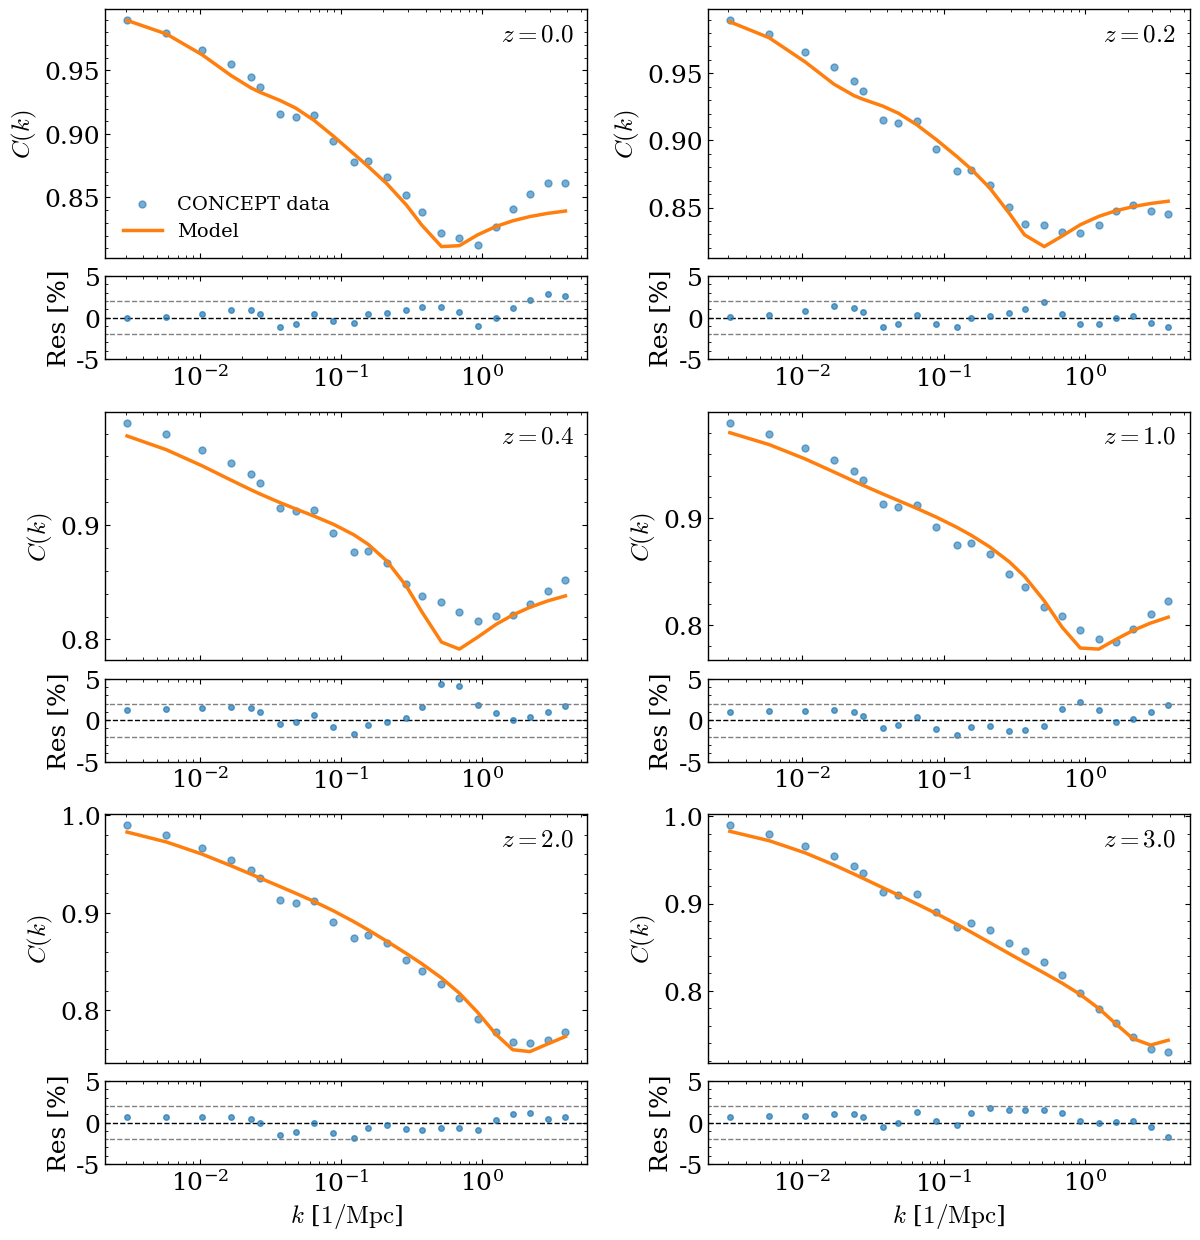

In [9]:
# For Test 7 (SIDR model, no fidm)
test_model(
    test_folder_name="test_7", 
    z_list=[0.0, 0.2, 0.4, 1.0, 2.0, 3.0], 
    dNeff_shift=0, 
    fidm_shift=-3.75,
)

In [18]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm

def test_model_grid(test_folders, test_params, default_z_list,
                    base_path="/home/storgaard/OneDrive/Speciale/HALOFIT/C_256+2048",
                    num_bins=25, res_lims=[-5, 5]):
    """
    Dynamically loads N-body data for 6 tests, plotting all z-slices for a given test 
    inside a single subplot. Arranged in a 3x2 grid.
    
    test_params: A dictionary defining specific parameters for each test folder.
                 Example:
                 {
                     "test_1": {"dNeff": 0.0, "fidm": 0.0},
                     "test_5": {"dNeff": 0.1, "fidm": 0.05, "custom_z": [0, 0.5, 1.0]} 
                 }
    """
    
    if len(test_folders) > 6:
        print("Warning: More than 6 folders provided. Only plotting the first 6.")
        test_folders = test_folders[:6]
        
    rows, cols = 3, 2
    fig = plt.figure(figsize=(14, 16))
    # Outer gridspec for the 6 tests
    gs_outer = gridspec.GridSpec(rows, cols, wspace=0.15, hspace=0.10)

    for i, folder in enumerate(test_folders):
        row = i // cols
        col = i % cols
        
        # Extract test-specific parameters (default to 0 if not found)
        params = test_params.get(folder, {})
        dNeff_shift = params.get("dNeff", 0)
        fidm_shift = params.get("fidm", 0)
        
        # Check if this test requires a custom z-list (like test 5)
        if "test_5" in folder or "custom_z" in params:
            z_list = params.get("custom_z", [0.0, 0.5, 1.0, 2.0]) # Replace with your actual test 5 z-slices
        else:
            z_list = default_z_list

        # Setup inner gridspec for Main vs Residual
        gs_inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_outer[i], 
                                                    height_ratios=[3, 1], hspace=0.05)
        
        ax_main = fig.add_subplot(gs_inner[0])
        ax_res  = fig.add_subplot(gs_inner[1], sharex=ax_main)
        
        # Generate distinct colors for the different redshifts in this subplot
        colors = cm.turbo(np.linspace(0, 0.9, len(z_list)))

        # Loop over the redshift slices for this specific test
        for j, z in enumerate(z_list):
            file_name = f"Ck_z{z:.2f}.txt"
            file_path = os.path.join(base_path, folder, file_name)
            color = colors[j]
            
            try:
                # 1. Load Raw N-body data
                data = np.loadtxt(file_path, skiprows=1)
                raw_k = data[:, 0]
                raw_C = data[:, 1]
                
                # 2. Log-k Binning
                k_bins = np.logspace(np.log10(raw_k.min()), np.log10(raw_k.max()), num_bins + 1)
                data_k, data_C = [], []
                
                for b in range(num_bins):
                    mask = (raw_k >= k_bins[b]) & (raw_k < k_bins[b+1])
                    if np.any(mask):
                        data_k.append(np.exp(np.mean(np.log(raw_k[mask]))))
                        data_C.append(np.mean(raw_C[mask]))
                
                data_k = np.array(data_k)
                data_C = np.array(data_C)

                # 3. Get Emulator Prediction
                model_res = combined_full_model(data_k, z, dNeff_shift, fidm_shift)
                model_k = model_res['k']
                model_C = model_res['C']

                # 4. Calculate Residuals (%)
                residuals_pct = (data_C / model_C - 1) * 100

                # --- Plot Main ---
                # Using scatter for data and solid line for the model
                ax_main.scatter(data_k, data_C, color=color, alpha=0.5, s=20, marker='o')
                ax_main.plot(model_k, model_C, color=color, lw=1.5, label=f'$z = {z}$', zorder=10)

                # Insert text saying which test is shown in this subplot
                names = {
                    "test_1": "Test 1: dNeff=+1.75, fidm=-1.75",
                    "test_3": "Test 2: dNeff=-2.0, fidm=+0.75",
                    "test_4": "Test 3: dNeff=+2.5, fidm=-2.5",
                    "test_5": "Test 4: Baseline at high-z",
                    "test_6": "Test 5: dNeff=+3.5, fidm=+3.5",
                    "test_7": "Test 6: SIDR model, no fidm"
                }
                ax_main.text(0.75, 0.90, f"{names.get(folder, folder)}", transform=ax_main.transAxes, 
                             verticalalignment='center', horizontalalignment='center', 
                             fontsize=10, color='k', fontname = 'Serif')

                # --- Plot Residuals ---
                ax_res.plot(data_k, residuals_pct, 'o', markersize=3, color=color, alpha=0.7)

            except FileNotFoundError:
                print(f"Warning: File {file_path} not found. Skipping redshift z={z} for {folder}.")
                
                

        # Formatting Main Panel
        # Only set y-labels for the left column
        if col == 0:
            ax_main.set_ylabel(r'$C(k)$')
        if row == 0 and col == 0:
            ax_main.legend(frameon=False, loc='lower left', fontsize='small', ncol=2)
        # Also make legend for high z slice in test 5 more visible
        if "test_5" in folder:
            ax_main.legend(frameon=False, loc='lower left', fontsize='small', ncol=2)
        plt.setp(ax_main.get_xticklabels(), visible=False)
        ax_main.set_xscale('log')
        ax_main.set_xlim(2e-3, 6)


        # Formatting Residual Panel
        ax_res.axhline(0, color='black', lw=1, ls='-')
        ax_res.hlines([2, -2], color='grey', lw=1, ls='--', xmin=1e-3, xmax=1e1) # Fixed xmin/xmax safely
        
        if col == 0:
            ax_res.set_ylabel(r'Res [%]')
        ax_res.set_ylim(*res_lims)
        # Change the res lims for test 5 and 6
        if "test_5" in folder:
            ax_res.set_ylim(-8, 8)
        elif "test_6" in folder:
            ax_res.set_ylim(-10, 17)
        
        # Only add x-labels to the bottom row of the outer grid
        if row == rows - 1:
            ax_res.set_xlabel(r'$k$ [$1/\mathrm{Mpc}$]')
        ax_res.set_xlim(2e-3, 6)

    fig.savefig("6_tests_comparison_ABM.pdf", dpi=300, bbox_inches='tight')
    plt.show()

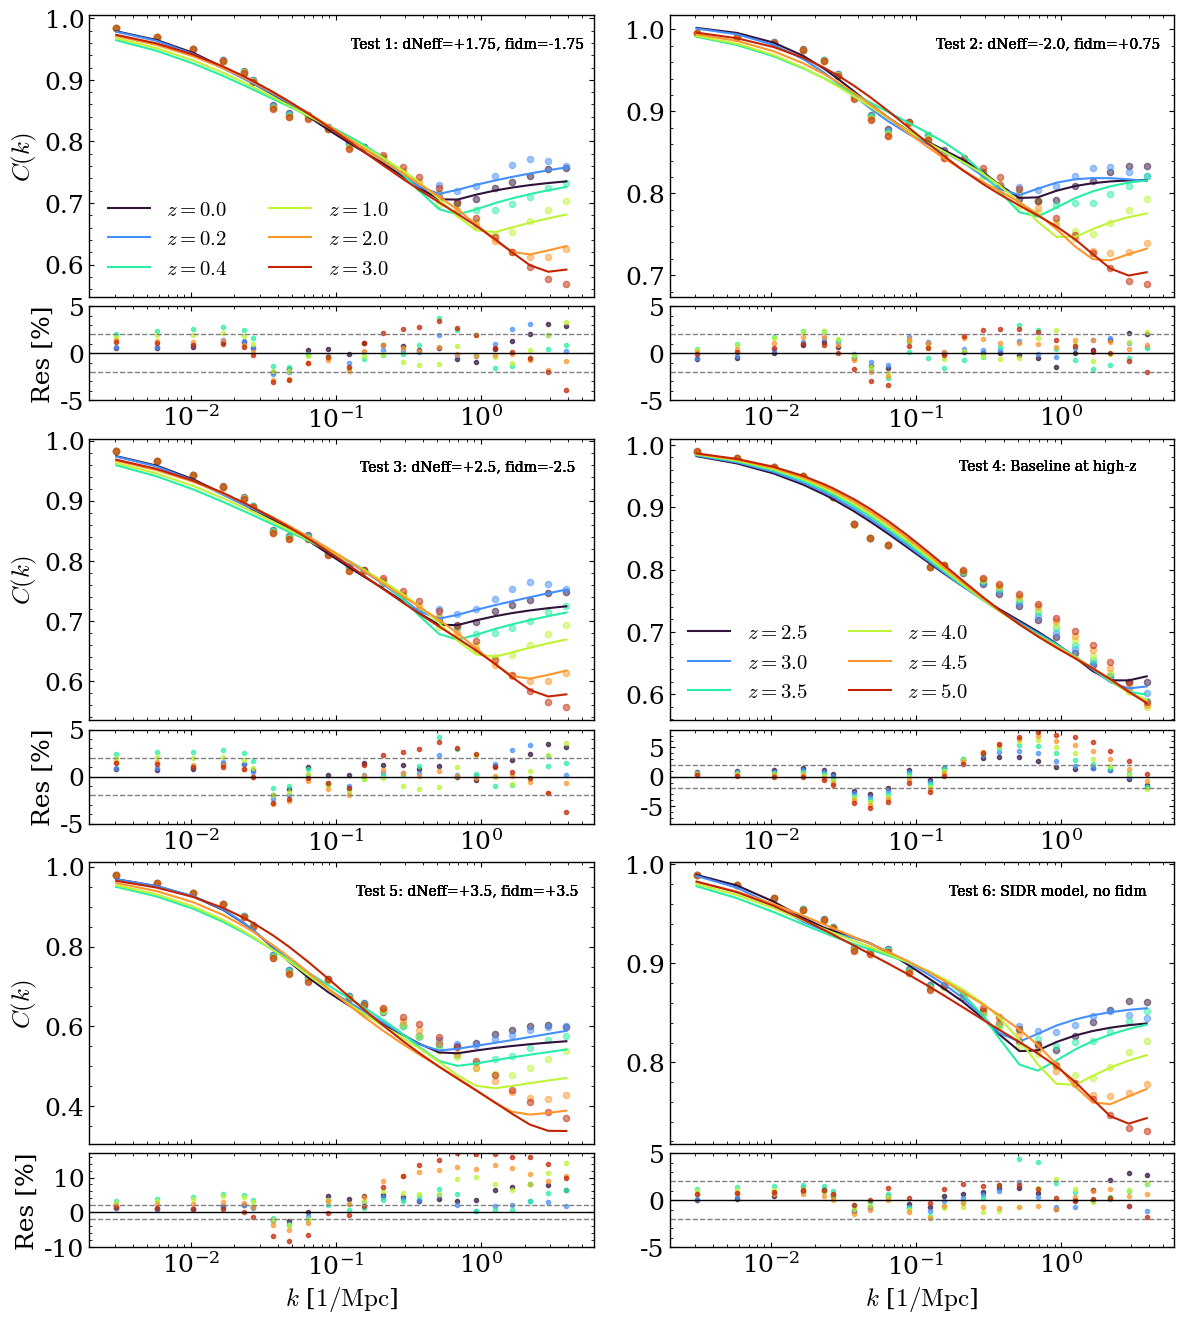

In [19]:
# ==========================================
# Example usage:
# ==========================================
folders = ["test_1", "test_3", "test_4", "test_5", "test_6", "test_7"]
params = {
    "test_1": {"dNeff": 1.75, "fidm": -1.75},
    "test_3": {"dNeff": -2.0, "fidm": 0.75},
    "test_4": {"dNeff": 2.5, "fidm": -2.5},
    "test_5": {"dNeff": 0.2, "fidm": 0.1, "custom_z": [2.5, 3.0, 3.5, 4.0, 4.5, 5.0]},
    "test_6": {"dNeff": 3.5, "fidm": 3.5},
    "test_7": {"dNeff": 0, "fidm": -3.75}
}
default_zs = [0.0, 0.2, 0.4, 1.0, 2.0, 3.0]

test_model_grid(folders, params, default_zs)